In [1]:
from __future__ import annotations
from typing import List, Tuple, Dict, Type
from abc import ABC, abstractmethod
import ast
import regex
import pandas as pd
from tqdm import tqdm
import os


from datasets import Dataset
import pandas as pd


class Utterance:
    text: str
    images: List[str]
    speaker: str | None

    def __init__(self, text: str, speaker: str | None = None):
        self.text = text
        self.speaker = speaker
        self.images = []

    def split(self) -> List[Utterance]:
        l = len(self.text)
        splits = []
        for i in range(1, l - 1):
            utr = Utterance(self.text[:i])
            utr.images = self.images
            splits.append(utr)
        return splits

    def add_image(self, image: str):
        self.images.append(image)

    def format_utterance(self) -> str:
        return "".join(
            ["[" + image + "]" for image in self.images] + [self.text]
        )


class Dialog:
    utterances: List[Utterance]

    def __init__(self, utterances: List[Utterance] | str):
        if isinstance(utterances, str):
            self.utterances = self.get_utterances(utterances)
        else:
            self.utterances = utterances

    def __getitem__(self, item: int) -> Utterance:
        return self.utterances[item]

    def __len__(self) -> int:
        return len(self.utterances)

    def format_dialog(self) -> str:
        return "\n".join(
            [utterance.format_utterance() for utterance in self.utterances]
        )

    def unroll(self) -> List[Dialog]:
        return [
            Dialog(self.utterances[:i]) for i in range(1, len(self.utterances))
        ]

    def create_splits(self) -> List[Dialog]:
        context = self.utterances[:-1]
        response = self.utterances[-1]
        response_splits = response.split()
        return [
            Dialog(context + [response_split])
            for response_split in response_splits
        ]

    @abstractmethod
    def get_utterances(self, inp: str) -> List[Utterance]:
        pass


class DialogCC(Dialog):
    def get_utterances(self, inp: str) -> List[Utterance]:
        utterances = []
        ls = ast.literal_eval(inp)
        for dictionary in ls:
            utterance = Utterance(
                text=dictionary["utterance"], speaker=dictionary["speaker"]
            )
            for image in dictionary["shared_image"]:
                utterance.add_image(image["image_url"])
            utterances.append(utterance)
        return utterances


"""
dialogue_id,dialogue,split
bst:174,"[{'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Andrik', 'utterance': ""I'm eagerly waiting on a bigger self-employed paycheck by the end of this month. Whoopeee"", 'utterance_idx': 0}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'person listening to music against a white background', 'image_url': 'https://ak1.picdn.net/shutterstock/videos/851851/thumb/1.jpg?i10c=img.resize(height:160)'}, {'caption': 'boy singing into a microphone .', 'image_url': 'https://media.istockphoto.com/photos/boy-singing-into-a-microphone-very-emotional-picture-id476816708?k=6&m=476816708&s=612x612&w=0&h=nxEuL83NGh88_2BdUOMlmgVa8VGxtCj3PAWrfXOcu44='}, {'caption': 'portrait of a young man singing into microphone', 'image_url': 'https://media.istockphoto.com/photos/portrait-of-a-young-man-singing-into-microphone-picture-id692080690?k=6&m=692080690&s=612x612&w=0&h=h_hWoiv7T_K3C9GC1_DepxhN-4Fo2-ZSuPGQhEhrr-8='}], 'speaker': 'Gena', 'utterance': 'Wow congrats! I recently got a job as a radio host! I love it.', 'utterance_idx': 1}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Andrik', 'utterance': 'Interesting! What time of day do you work?', 'utterance_idx': 3}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gena', 'utterance': ""Usually early mornings because that's when people are commuting to work. What about you?"", 'utterance_idx': 4}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Andrik', 'utterance': ""That's the only time of day I listen to the radio! My hours are regular office hours. I am really enjoying my new gig. Sounds like you are too?"", 'utterance_idx': 5}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gena', 'utterance': 'Ahh so the typical 9-5? My husband is the same, but he usually works overtime by having to go to corporate dinners haha. Yeah I love it.', 'utterance_idx': 6}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Andrik', 'utterance': 'Yep exactly. Do you get lots of people calling in to your show?', 'utterance_idx': 7}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gena', 'utterance': 'Not usually, people only really call in for the competitions we run.', 'utterance_idx': 8}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Andrik', 'utterance': ""Ah ha. I've actually called in and won on radio shows before! Do you get decent vacation time?"", 'utterance_idx': 9}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gena', 'utterance': ""Really?! What did you win? Yeah, it's the standard amount you'd expect really, but every day feels like a holiday when you love your job :)"", 'utterance_idx': 10}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'person and teen pop artist of pop rock artist in concert .', 'image_url': 'https://media.gettyimages.com/photos/nick-and-kevin-jonas-of-the-jonas-brothers-in-concert-at-madison-on-picture-id82241380?k=6&m=82241380&s=612x612&w=0&h=nohpIFSy9aA58clWVaafUPZBld2-AFuGEPeI3Rk5SLU='}, {'caption': 'person and teen pop artist of pop rock artist in concert .', 'image_url': 'https://media.gettyimages.com/photos/nick-and-kevin-jonas-of-the-jonas-brothers-in-concert-at-madison-on-picture-id82241386?k=6&m=82241386&s=612x612&w=0&h=yw5vI4FHZQ0db_03Ruq1rNuSovFbQ1uiZOTO839E9j8='}], 'speaker': 'Andrik', 'utterance': ""I totally agree! You gotta do what you love, find the right mix of people! I've won concert tickets!"", 'utterance_idx': 11}]",test
bst:424,"[{'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jolinda', 'utterance': 'Trance music', 'utterance_idx': 0}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jamari', 'utterance': ""Not my favorite but it's interesting. I pretty much like everything except country and jazz. What about you?"", 'utterance_idx': 1}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'a large variety of colorful candy', 'image_url': 'https://media.istockphoto.com/photos/large-variety-of-colorful-candy-picture-id182866680?k=6&m=182866680&s=612x612&w=0&h=UMcrFT-nu1cDSyo7LDZHabB0Fv5oxhT0Eiqb-eY7zUI='}], 'speaker': 'Jolinda', 'utterance': 'I love country music, and my favorite food is gummy bears!', 'utterance_idx': 2}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'christmas cookies recipe - these moist treats will have everyone reaching for more .', 'image_url': 'https://i.pinimg.com/736x/b1/fa/a4/b1faa4077ef79fed095c1fc6c8d5e1bb.jpg'}], 'speaker': 'Jamari', 'utterance': ""Aww gummy bears. Brings me back to my childhood. I love holiday reese's."", 'utterance_idx': 4}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jolinda', 'utterance': ""I am lactose intolerant, so there only certain sweets I can eat! But holiday reese's are good too!"", 'utterance_idx': 6}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jamari', 'utterance': 'Oh I hate that. Do you enjoy reading?', 'utterance_idx': 7}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jolinda', 'utterance': 'Yes, I love to read. What about you?', 'utterance_idx': 8}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jamari', 'utterance': 'One of my favorite things to do during free time. What kind of books do you like?', 'utterance_idx': 9}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'create a dragon from an image', 'image_url': 'http://www.pxleyes.com/images/tutorials/submissionsteps/fullsize/2511_step12_4e183b34512a0.jpg'}], 'speaker': 'Jolinda', 'utterance': 'I like fiction books, books about dragons and fairy tale. What about you?', 'utterance_idx': 10}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'bloody hands on a white background , zombie', 'image_url': 'https://media.istockphoto.com/photos/bloody-hands-on-a-white-background-zombie-picture-id485408680?k=6&m=485408680&s=612x612&w=0&h=2808gvZN9UEefRool6p9KseWNdjiyCdCXXxnM8hW9Wg='}, {'caption': 'zombies pour into the city', 'image_url': 'http://www.nedmartin.org/v3/_img/20080525/s/IMG_6580.jpg'}], 'speaker': 'Jamari', 'utterance': 'Fiction is what I enjoy as well. I have really gotten into zombie books lately.', 'utterance_idx': 12}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Jolinda', 'utterance': 'I enjoy zombie books as well, they always have good endings!', 'utterance_idx': 14}]",test
bst:900,"[{'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Latonia', 'utterance': 'It makes me think of the good old days when I was a kid when I listen to the music in my aunts car', 'utterance_idx': 0}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': ""I can see how that could be soothing if you didn't get motion sickness"", 'utterance_idx': 1}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Latonia', 'utterance': 'Do you run /', 'utterance_idx': 2}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': 'I love running, but it needs to be in the right area. You?', 'utterance_idx': 3}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'woman running in a park', 'image_url': 'https://ak8.picdn.net/shutterstock/videos/2594288/thumb/1.jpg?i10c=img.resize(height:160)'}, {'caption': 'dynamic pretty woman running in a forest in slow motion', 'image_url': 'https://ak4.picdn.net/shutterstock/videos/4721678/thumb/5.jpg'}, {'caption': 'young woman jogging on a road in city park , forest in slow motion .', 'image_url': 'https://ak4.picdn.net/shutterstock/videos/26565224/thumb/1.jpg?i10c=img.resize(height:160)'}, {'caption': 'girl is running on the background of houses', 'image_url': 'https://ak2.picdn.net/shutterstock/videos/19462762/thumb/1.jpg?i10c=img.resize(height:160)'}, {'caption': 'a woman warming up and jogging along a lake', 'image_url': 'https://ak0.picdn.net/shutterstock/videos/17586970/thumb/1.jpg'}, {'caption': 'happy woman jogging in the forest , slow motion', 'image_url': 'https://ak4.picdn.net/shutterstock/videos/2418494/thumb/2.jpg'}, {'caption': 'young woman jogging in the forest , slow motion , dolly shot', 'image_url': 'https://ak1.picdn.net/shutterstock/videos/2429981/thumb/10.jpg'}, {'caption': 'woman running in the beach with the sun behind', 'image_url': 'https://ak3.picdn.net/shutterstock/videos/9516533/thumb/2.jpg?i10c=img.resize(height:160)'}, {'caption': 'young woman jogging in the forest , slow motion , dolly shot', 'image_url': 'https://ak2.picdn.net/shutterstock/videos/2418122/thumb/12.jpg?i10c=img.resize(height:160)'}, {'caption': 'what are the benefits of jogging ?', 'image_url': 'https://edc2.healthtap.com/ht-staging/user_answer/reference_image/5388/large/jogging.jpeg?1386670288'}], 'speaker': 'Latonia', 'utterance': ""It's my enjoyment, my stress reliever."", 'utterance_idx': 4}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': 'That is a great stress reliever. How far do you normally run?', 'utterance_idx': 6}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'leaves are falling in the autumn forest , real time , no sound', 'image_url': 'https://ak0.picdn.net/shutterstock/videos/20778160/thumb/1.jpg?i10c=img.resize(height:160)'}, {'caption': 'autumn leaves fall from a tree in a wild forest with sound', 'image_url': 'https://ak4.picdn.net/shutterstock/videos/32337634/thumb/1.jpg'}, {'caption': 'a cold wind and snow on bare trees', 'image_url': 'https://ak0.picdn.net/shutterstock/videos/21250840/thumb/1.jpg'}, {'caption': 'looking upward and falling gently backward from a sunshine filled fresh green tree canopy , gently rustling in the breeze', 'image_url': 'https://ak0.picdn.net/shutterstock/videos/26817100/thumb/1.jpg?i10c=img.resize(height:160)'}, {'caption': 'the wind shakes autumn yellow leaves on bare branches .', 'image_url': 'https://ak4.picdn.net/shutterstock/videos/33784954/thumb/1.jpg'}, {'caption': 'tree tops dance in the wind during fall', 'image_url': 'https://ak9.picdn.net/shutterstock/videos/12355889/thumb/1.jpg'}, {'caption': 'looking upwards in the forest with turn to the side', 'image_url': 'https://ak5.picdn.net/shutterstock/videos/29138575/thumb/1.jpg'}, {'caption': 'birds sing in a fresh green forest', 'image_url': 'https://ak2.picdn.net/shutterstock/videos/29030572/thumb/1.jpg'}], 'speaker': 'Latonia', 'utterance': 'Bout 4 miles easy, I like to run when its cool and windy', 'utterance_idx': 7}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': 'Wow. I only make it about a mile, mile and a half. When I have time.', 'utterance_idx': 9}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Latonia', 'utterance': 'Its all in the mind, once you can believe it you can do it', 'utterance_idx': 10}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': 'Do you like any other sports?', 'utterance_idx': 11}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Latonia', 'utterance': 'Not really,', 'utterance_idx': 12}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': 'Oh, do you listen to music while you run?', 'utterance_idx': 13}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Latonia', 'utterance': 'I do, helps encourage me', 'utterance_idx': 14}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Gregg', 'utterance': 'What are some of your favorites?', 'utterance_idx': 15}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Latonia', 'utterance': 'R&b preferably, what about you?', 'utterance_idx': 16}]",test
bst:489,"[{'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Kooper', 'utterance': 'Badminton', 'utterance_idx': 0}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'children boys and girls playing and enjoying on swings in a park', 'image_url': 'http://c8.alamy.com/comp/A01R39/children-boys-and-girls-playing-and-enjoying-on-swings-in-a-park-at-A01R39.jpg'}, {'caption': 'children playing in the playground', 'image_url': 'http://l7.alamy.com/zooms/73127a2e523745ef86259e1fa265abb7/mount-pilatus-switzerland-23-august-2006-children-playing-in-the-playground-g1r84c.jpg'}, {'caption': ""a children 's play area in a city"", 'image_url': 'http://l7.alamy.com/zooms/d70275135591496bbb4f547987d01882/a-childrens-play-area-in-a-uk-city-c26mjj.jpg'}], 'speaker': 'Juliana', 'utterance': 'I usually play at our local park. I have a group of friends I meet up with on friday afternoons.', 'utterance_idx': 1}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Kooper', 'utterance': 'That seems like fun to play outdoors, do you play indoors if it rains or snows?', 'utterance_idx': 3}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'the basketball court opens onto a game room with a kitchen , pool table and fireplace .', 'image_url': 'https://si.wsj.net/public/resources/images/BN-RB100_EDWARD_M_20161202134300.jpg'}], 'speaker': 'Juliana', 'utterance': ""Lol. Well, we have been known to play in my garage if all else fails. I don't use the garage for my car, so it's perfect!"", 'utterance_idx': 4}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Kooper', 'utterance': 'Sounds fun! I really want to enter a tournament some day!', 'utterance_idx': 6}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Juliana', 'utterance': ""That would be fun. I'm a competitive person so that sounds like something I would enjoy!"", 'utterance_idx': 7}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Kooper', 'utterance': 'You should start playing competitively, and go for the gold in the olympics games!', 'utterance_idx': 8}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Juliana', 'utterance': 'Have you ever played in a tournament and won?', 'utterance_idx': 9}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Kooper', 'utterance': ""Not yet, I'm going to sign up for my first one soon!"", 'utterance_idx': 10}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Juliana', 'utterance': 'Does your ymca offer tournaments there?', 'utterance_idx': 11}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'people in a group exercising on the beach after work', 'image_url': 'http://l7.alamy.com/zooms/5780acd890ae44a9884e8e69dfb40040/people-in-a-group-exercising-on-the-beach-after-work-in-santa-monica-f9e72g.jpg'}], 'speaker': 'Kooper', 'utterance': ""Badminto isn't very popular here therefore I have to go to another location. They really like to play raquetball here by the beach!"", 'utterance_idx': 12}]",test
bst:459,"[{'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Triton', 'utterance': ""I'm working so hard to see if I make the police academy."", 'utterance_idx': 0}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Amyah', 'utterance': 'Sorry to hear about your mother. Good for you! Better job than mine working at target', 'utterance_idx': 1}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Triton', 'utterance': ""Target's a great store. I'm glad I've got one so close to home. How long have you worked there?"", 'utterance_idx': 2}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Amyah', 'utterance': 'Just started 3 days ago! I get a discount on dog biscuits. I buy my dog one after work every day. But I have a secret!', 'utterance_idx': 3}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Triton', 'utterance': ""Oh yeah? What's that? You tell me yours and I'll tell you mine"", 'utterance_idx': 4}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Amyah', 'utterance': 'The dog treats! I cant help', 'utterance_idx': 5}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Triton', 'utterance': ""Lol! Some of them do look tempting. My secret: I'm afraid of the dark. I hope they don't figure that out at the police academy!"", 'utterance_idx': 6}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Amyah', 'utterance': 'Hahahahah. We have that in common!', 'utterance_idx': 7}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Triton', 'utterance': ""I'll have to give the dog treat thing a try!"", 'utterance_idx': 8}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Amyah', 'utterance': 'I can only eat them in the dark! Lol', 'utterance_idx': 9}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Triton', 'utterance': ""Lolol! That's the funniest thing I've heard all day! I'll have to tell my mom that one. She's really my best friend"", 'utterance_idx': 10}, {'description': '', 'rationale': '', 'shared_image': [{'caption': 'dog - the cutest dog in the world', 'image_url': 'https://i.pinimg.com/736x/a9/8c/55/a98c55eb884609c0a197c84ddef9d426--cutest-dog-in-the-world-the-cutest.jpg'}, {'caption': 'do you know where you dog can travel in the car ?', 'image_url': 'https://i2-prod.somersetlive.co.uk/news/somerset-news/article516021.ece/ALTERNATES/s615/Dog-laws-3.jpg'}, {'caption': 'the most cutest dog in the world - photo #', 'image_url': 'https://i.ytimg.com/vi/ldGPQtVz6QI/maxresdefault.jpg'}, {'caption': 'the most cutest dog in the world - photo #', 'image_url': 'http://bestpickr.com/wp-content/uploads/Worlds-Cutest-Small-Dog-Picture.jpg'}, {'caption': 'animal of the most beautiful dogs', 'image_url': 'https://i.pinimg.com/736x/94/09/d4/9409d4aec4d0a12e7318c58344a31ed0--most-beautiful-dogs-amazing-dogs.jpg'}, {'caption': 'a photo of a puppy .', 'image_url': 'https://i.pinimg.com/736x/d5/2b/f5/d52bf5a5520c01da8b7ddc0be53487b7--toy-chihuahua-chihuahua-puppies-for-sale.jpg'}, {'caption': 'boo the dog with a hairdo', 'image_url': 'https://i.pinimg.com/736x/67/12/9e/67129e496aea7c965976ae4cd3a4ba29--boo-puppy-boo-dog.jpg'}, {'caption': 'photo of aggressive dog on the grass', 'image_url': 'http://1.bp.blogspot.com/-bPiRrP5G_UY/UNDZUhViJcI/AAAAAAAAI-U/qRvpHAdHHeE/s640/photo-of-a-aggressive-dog-on-a-grass-field-at-autumn-hd-dog-wallpaper.jpg'}, {'caption': 'older : dogs could live for years with the new drug', 'image_url': 'https://i2-prod.mirror.co.uk/incoming/article6955224.ece/ALTERNATES/s615/Happy-smiling-dog.jpg'}, {'caption': ""but there 's much more to a dog 's nose than you think !"", 'image_url': 'https://i.pinimg.com/736x/11/18/59/11185979e5b409b0199763ba8d7a8db3--dog-nose-print-golden-retrievers.jpg'}], 'speaker': 'Amyah', 'utterance': 'My dog is not quite my best friend, but she sure does cheer me up a ton!', 'utterance_idx': 11}]",test
"""


class DialogData(Dataset):
    def __init__(self, path: str)->None:
        """
        Custom Dataset class extending Hugging Face's Dataset.

        Args:
            path (str): Path to the dataset file

        Returns:
            None
        """
        self.path = path
        self.dialogs = self.parse_raw_file()
    
    def __len__(self):
        return len(self.dialogs)
    
    def __getitem__(self, idx: int) -> Tuple[str, Dialog]:
        return self.dialogs[idx]


    @abstractmethod
    def parse_raw_file(self) -> List[Tuple[str, Dialog]]:
        """
        Shall parse the dataset file and return a list of Tuples containing
        dialog idx and dialog
        """
        pass


class DialogCCData(DialogData):
    def parse_raw_file(self) -> List[Tuple[str, Dialog]]:
        """
        Parses the raw dataset file and returns a list of Tuples containing
        dialog idx, dialog and split
        """
        df = pd.read_csv(self.path)
        dialogs = []
        for idx, row in tqdm(df.iterrows()):
            try:
                dialog = DialogCC(row["dialogue"])
            except Exception as e:
                print(e)
                print(row["dialogue"])
                break
            dialogs.append((row["dialogue_id"], dialog))
        return dialogs


/home/anubhab-pg/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
path = "../../data/DialogCC/train.csv"
dialog_data = DialogCCData(path)
print(len(dialog_data))

68402it [00:20, 3414.67it/s]

68402


In [22]:
print(dialog_data[0][1].format_dialog())

I like mexican food but I hate veggies and fruit but I pretend
No I haven't. Are they good?
There fantastic I've only had the frozen ones in tv dinners but I always enjoy them
That's cool. I'll have to try those out sometime
Do you prefer pork or beef meatballs in your pasta?
I like either really. Turkey meatballs are good too
[https://thegardeningcook.com/wp-content/uploads/2016/09/abruzzese-meatballs-buttery-pasta.jpg][https://drscdn.500px.org/photo/149827269/m%3D900_s%3D1_k%3D1_a%3D1/v2?webp=true&v=3&sig=020985fd8da8596719ac77b37a81954bf3685a4a44be765b1c233e71e46c75f9][http://food.fnr.sndimg.com/content/dam/images/food/fullset/2010/10/29/1/CCWID108_Spaghetti-and-Meatballs_s4x3.jpg.rend.hgtvcom.616.462.suffix/1371594924971.jpeg][https://i.pinimg.com/736x/50/81/cf/5081cf50b9f336323eecd64c38f14af2--delicious-pasta-recipes-recipe-for-pasta.jpg][https://i.pinimg.com/736x/00/54/c2/0054c2e982ee9dc9e92bc27a140f04d3--chicken-spaghetti-recipes-cheese-spaghetti.jpg][https://i.pinimg.com/736x/1

In [12]:
a = [{'description': '', 'rationale': '', 'shared_image': [{'caption': 'large round clock shows half of the fourth', 'image_url': 'https://thumb7.shutterstock.com/display_pic_with_logo/884251/210498781/stock-photo-large-round-clock-shows-half-of-the-fourth-210498781.jpg'}, {'caption': 'simple basic model of a wall clock', 'image_url': 'https://media.istockphoto.com/photos/simple-basic-model-of-a-wall-clock-picture-id146815061?k=6&m=146815061&s=612x612&w=0&h=Dv9WvfH7cVXu9lVEO3Nkmg_m5C_BnKShqW1u6xtOPmI='}, {'caption': 'round clock shows half of the second', 'image_url': 'https://thumb7.shutterstock.com/display_pic_with_logo/884251/251824585/stock-photo-round-clock-shows-half-of-the-second-251824585.jpg'}, {'caption': 'a simple illustrated clock for teaching the time', 'image_url': 'https://thumb1.shutterstock.com/display_pic_with_logo/58358/58358,1174225181,8/stock-vector-a-simple-illustrated-clock-for-teaching-the-time-2895242.jpg'}, {'caption': 'round clock shows half of the second photo', 'image_url': 'https://us.123rf.com/450wm/dimedrol68/dimedrol681608/dimedrol68160800026/62155352-round-clock-shows-half-of-the-second.jpg?ver=6'}, {'caption': 'large round clock shows half of the third photo', 'image_url': 'https://us.123rf.com/450wm/dimedrol68/dimedrol681608/dimedrol68160800100/62155625-large-round-clock-shows-half-of-the-third.jpg?ver=6'}, {'caption': 'five to eight on a round clock face', 'image_url': 'https://thumb1.shutterstock.com/display_pic_with_logo/884251/210967240/stock-photo-five-to-eight-on-a-round-clock-face-210967240.jpg'}, {'caption': 'an illustration of an analogue grey clock', 'image_url': 'https://thumb9.shutterstock.com/display_pic_with_logo/58358/58358,1228135953,2/stock-photo-an-illustration-of-a-analogue-grey-clock-21352945.jpg'}, {'caption': 'large office round the clock shows photo', 'image_url': 'https://us.123rf.com/450wm/dimedrol68/dimedrol681404/dimedrol68140400041/27936068-large-office-round-the-clock-shows-almost-five-hours.jpg?ver=6'}, {'caption': 'almost a hour on round clock face', 'image_url': 'https://thumb10.shutterstock.com/display_pic_with_logo/884251/532054357/stock-photo-almost-an-hour-on-round-clock-face-532054357.jpg'}], 'speaker': 'Adelaida', 'utterance': 'I waited for my sister all day today. She was 6 hours late', 'utterance_idx': 0}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Julianna', 'utterance': 'Why was she so late, thats terrible', 'utterance_idx': 2}, {'description': '', 'rationale': '', 'shared_image': [], 'speaker': 'Adelaida', 'utterance': 'I have no idea. I didn{t get to do anything I planned today because I had her kids.', 'utterance_idx': 3}]

In [15]:
a = [{'a': {'b': 'c'}, 'd': {'e': 'f'}}]
a = str(a)

In [16]:
a

"[{'a': {'b': 'c'}, 'd': {'e': 'f'}}]"

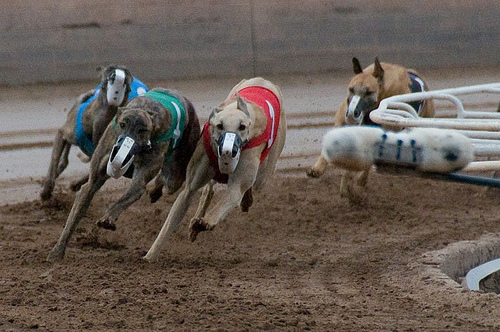

In [1]:
from PIL import Image

image_path = "/home/anubhab-pg/CHAT-AS-MULTIMODAL/data/MMDD/images/flickr30k_images/flickr30k_images/2451114871.jpg"
image = Image.open(image_path)
image.show()
